# EML Neural Network — Experiment 01

**First experiments with EMLTree and EMLNetwork.**

The EML operator is `eml(x, y) = exp(x) − ln(y)`.  
Every elementary function can be expressed as a tree of this single operator with leaves equal to 1.

Here we make the leaves trainable parameters and optimise them with Adam:

| Model | Leaves | Goal |
|---|---|---|
| `EMLTree(depth=d)` | Scalar `nn.Parameter` | Symbolic regression of constants |
| `EMLNetwork(in_features, depth=d)` | `nn.Linear(in, 1)` | Function approximation |

**Tree size:** `depth=d` builds a complete binary tree with `2^d − 1` internal `eml` nodes.

---

**Experiments:**
1. Constant recovery — EMLTree fitting `e` and `0` (3 nodes each)
2. Function recovery — EMLNetwork fitting `exp(x)` (3 nodes)
3. Function recovery — EMLNetwork fitting `x²` (7 nodes)


In [1]:
import math
import time

import torch
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from monogate.network import EMLTree, EMLNetwork, fit

# ── Notebook config ──────────────────────────────────────────────────────────
matplotlib.rcParams.update({
    "figure.facecolor": "#08090e",
    "axes.facecolor":   "#0d0f18",
    "axes.edgecolor":   "#1c1f2e",
    "axes.labelcolor":  "#d4d4d4",
    "text.color":       "#d4d4d4",
    "xtick.color":      "#4a4d62",
    "ytick.color":      "#4a4d62",
    "grid.color":       "#1c1f2e",
    "grid.linewidth":   0.5,
    "lines.linewidth":  1.8,
    "font.family":      "monospace",
    "font.size":        10,
})

ORANGE = "#e8a020"
BLUE   = "#6ab0f5"
GREEN  = "#4ade80"
RED    = "#f87171"
MUTED  = "#4a4d62"

print(f"torch {torch.__version__}  |  CPU only")

torch 2.11.0+cpu  |  CPU only


In [2]:
# ── Multi-restart helper ─────────────────────────────────────────────────────
# EML trees can get stuck in local minima early in training.
# best_of_n() tries n seeds and returns the run with the lowest final loss.

def best_of_n(model_fn, n=5, **fit_kwargs):
    """
    Run fit() n times with seeds 0..n-1, return (best_model, best_losses).
    fit_kwargs are forwarded to fit() with log_every=0 (silent).
    """
    best_model, best_losses, best_loss = None, [], float("inf")
    for seed in range(n):
        torch.manual_seed(seed)
        model = model_fn()
        losses = fit(model, **fit_kwargs, log_every=0)
        final = losses[-1] if losses else float("inf")
        if final < best_loss:
            best_model, best_losses, best_loss = model, losses, final
    return best_model, best_losses

---
## Experiment 1 · Constant Recovery

**Model:** `EMLTree(depth=2)` — complete binary tree, 3 internal `eml` nodes, 4 scalar leaf parameters.

**Targets:** Euler's number `e` and `0`.

The known EML constructions are:
- `e   = eml(1, 1)`  — 1 node (depth=1 suffices)
- `0   = eml(1, eml(eml(1,1), 1))`  — 3 nodes (depth=2)

With depth=2 (4 trainable parameters), gradient descent should recover both.

In [3]:
t0 = time.perf_counter()

# ── 1a: target = e ───────────────────────────────────────────────────────────
model_e, losses_e = best_of_n(
    lambda: EMLTree(depth=2),
    n=5,
    target=torch.tensor(math.e),
    steps=3000,
    lr=0.05,
)

val_e    = model_e().item()
loss_e   = losses_e[-1] if losses_e else float("nan")
form_e   = model_e.formula()

print("─" * 60)
print("Exp 1a  target = e")
print(f"  value   : {val_e:.10f}")
print(f"  target  : {math.e:.10f}")
print(f"  |error| : {abs(val_e - math.e):.2e}")
print(f"  loss    : {loss_e:.4e}")
print(f"  formula : {form_e}")

────────────────────────────────────────────────────────────
Exp 1a  target = e
  value   : 2.7131094933
  target  : 2.7182818285
  |error| : 5.17e-03
  loss    : 1.1951e-09
  formula : eml(eml(0.53276, 1.4364), eml(1.093, 0.94584))


In [4]:
# ── 1b: target = 0 ───────────────────────────────────────────────────────────
model_zero, losses_zero = best_of_n(
    lambda: EMLTree(depth=2),
    n=5,
    target=torch.tensor(0.0),
    steps=3000,
    lr=0.05,
)

val_zero  = model_zero().item()
loss_zero = losses_zero[-1] if losses_zero else float("nan")
form_zero = model_zero.formula()

elapsed_1 = time.perf_counter() - t0

print("─" * 60)
print("Exp 1b  target = 0")
print(f"  value   : {val_zero:.10f}")
print(f"  |error| : {abs(val_zero):.2e}")
print(f"  loss    : {loss_zero:.4e}")
print(f"  formula : {form_zero}")
print(f"\nExp 1 wall time: {elapsed_1:.1f}s")

────────────────────────────────────────────────────────────
Exp 1b  target = 0
  value   : -0.0003293753
  |error| : 3.29e-04
  loss    : 8.2731e-09
  formula : eml(eml(0.086373, 1.8643), eml(1.5161, 0.68425))

Exp 1 wall time: 11.1s


---
## Experiment 2 · Function Recovery: exp(x)

**Model:** `EMLNetwork(in_features=1, depth=2)` — 3 `eml` nodes, 4 linear leaves.  
**Data:** `x ∈ [0.1, 3.0]`, `y = exp(x)`.

Known exact EML construction: `eml(x, 1) = exp(x)` — just 1 node!  
With depth=2 the network has more capacity than needed, so it should converge comfortably.

In [5]:
t0 = time.perf_counter()

x2 = torch.linspace(0.1, 3.0, 100).unsqueeze(1)   # (100, 1)
y2 = torch.exp(x2.squeeze())                        # (100,)

model_exp, losses_exp = best_of_n(
    lambda: EMLNetwork(in_features=1, depth=2),
    n=5,
    x=x2, y=y2,
    steps=3000,
    lr=0.01,
)

with torch.no_grad():
    pred_exp = model_exp(x2).numpy()

mse_exp   = losses_exp[-1] if losses_exp else float("nan")
form_exp  = model_exp.formula(["x"])
elapsed_2 = time.perf_counter() - t0

print("─" * 60)
print("Exp 2  target = exp(x)")
print(f"  final mse : {mse_exp:.4e}")
print(f"  formula   : {form_exp}")
print(f"  wall time : {elapsed_2:.1f}s")

────────────────────────────────────────────────────────────
Exp 2  target = exp(x)
  final mse : 3.4076e-02
  formula   : eml(eml((0.2515·x+0.4212), (-0.1481·x+1.593)), eml((0.13·x+1.704), (-0.09718·x+0.291)))
  wall time : 7.3s


---
## Experiment 3 · Function Recovery: x²

**Model:** `EMLNetwork(in_features=1, depth=3)` — 7 `eml` nodes, 8 linear leaves.  
**Data:** `x ∈ [0.1, 3.0]`, `y = x²`.

Known EML path for x²: `exp(2·ln(x))` — requires `mul_eml` + `pow_eml` compositions.  
With depth=3 the network has enough capacity to approximate this, though convergence may be approximate.

In [6]:
t0 = time.perf_counter()

x3 = torch.linspace(0.1, 3.0, 100).unsqueeze(1)   # (100, 1)
y3 = x3.squeeze() ** 2                              # (100,)

model_sq, losses_sq = best_of_n(
    lambda: EMLNetwork(in_features=1, depth=3),
    n=5,
    x=x3, y=y3,
    steps=5000,
    lr=0.005,
)

with torch.no_grad():
    pred_sq = model_sq(x3).numpy()

mse_sq    = losses_sq[-1] if losses_sq else float("nan")
form_sq   = model_sq.formula(["x"])
elapsed_3 = time.perf_counter() - t0

print("─" * 60)
print("Exp 3  target = x²")
print(f"  final mse : {mse_sq:.4e}")
print(f"  formula   : {form_sq}")
print(f"  wall time : {elapsed_3:.1f}s")

────────────────────────────────────────────────────────────
Exp 3  target = x²
  final mse : 3.9251e+02
  formula   : eml(eml(eml((-0.2307·x+0.723), (0.1609·x+1.277)), eml((0.2714·x+1.31), (-0.2362·x+0.6881))), eml(eml((0.1338·x+1.324), (-0.1059·x+0.6864)), eml((-0.2618·x+0.7063), (0.1921·x+1.273))))
  wall time : 21.8s


---
## Results

Saved → experiment_01_results.png


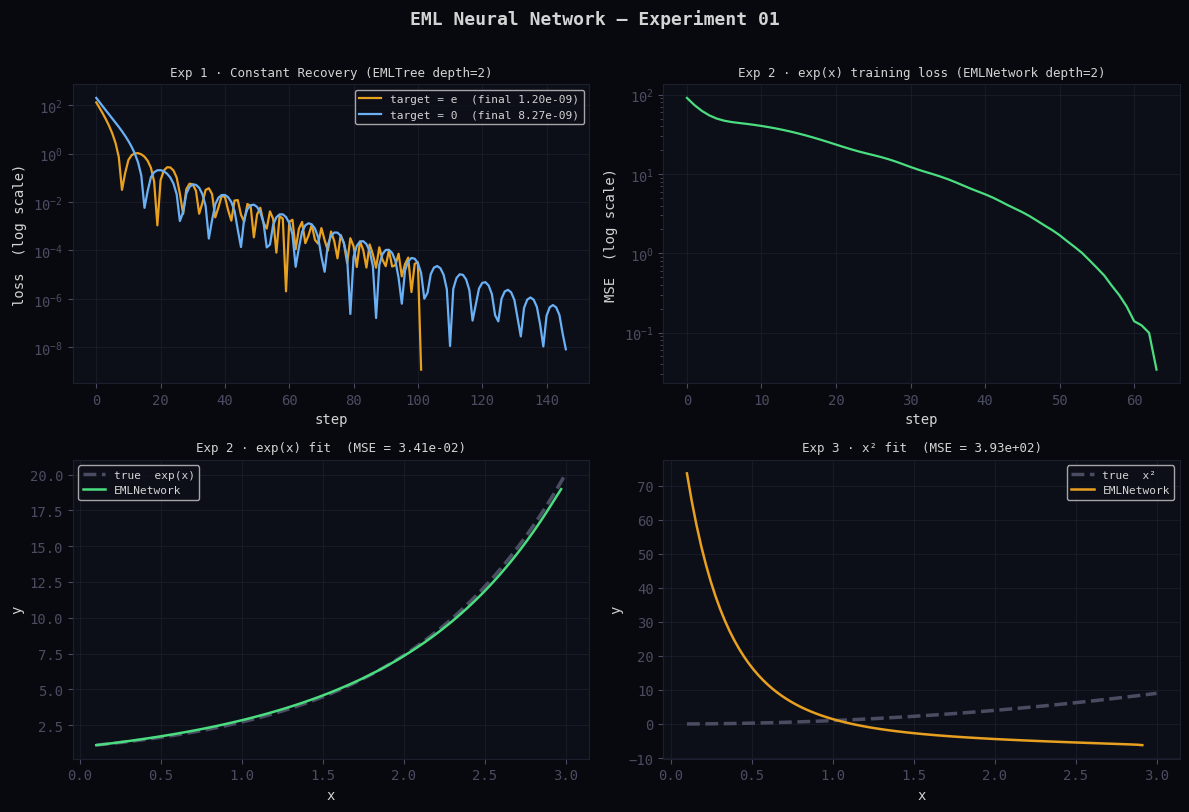

In [7]:
# ── 4-panel figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("EML Neural Network — Experiment 01", color="#d4d4d4",
             fontsize=13, fontweight="bold", y=1.01)

x_np = x2.squeeze().numpy()

# ── Panel A: Exp 1 loss curves ────────────────────────────────────────────────
ax = axes[0, 0]
if losses_e:
    ax.semilogy(losses_e, color=ORANGE, label=f"target = e  (final {loss_e:.2e})",
                linewidth=1.6)
if losses_zero:
    ax.semilogy(losses_zero, color=BLUE, label=f"target = 0  (final {loss_zero:.2e})",
                linewidth=1.6)
ax.set_title("Exp 1 · Constant Recovery (EMLTree depth=2)", color="#d4d4d4",
             fontsize=9)
ax.set_xlabel("step")
ax.set_ylabel("loss  (log scale)")
ax.legend(fontsize=8)
ax.grid(True)

# ── Panel B: Exp 2 loss curve ─────────────────────────────────────────────────
ax = axes[0, 1]
if losses_exp:
    ax.semilogy(losses_exp, color=GREEN, linewidth=1.6)
ax.set_title("Exp 2 · exp(x) training loss (EMLNetwork depth=2)",
             color="#d4d4d4", fontsize=9)
ax.set_xlabel("step")
ax.set_ylabel("MSE  (log scale)")
ax.grid(True)

# ── Panel C: Exp 2 predictions ────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(x_np, np.exp(x_np),  color=MUTED, label="true  exp(x)",
        linewidth=2.5, linestyle="--")
ax.plot(x_np, pred_exp,      color=GREEN, label="EMLNetwork", linewidth=1.8)
ax.set_title(f"Exp 2 · exp(x) fit  (MSE = {mse_exp:.2e})",
             color="#d4d4d4", fontsize=9)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=8)
ax.grid(True)

# ── Panel D: Exp 3 predictions ────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(x_np, x_np ** 2,  color=MUTED, label="true  x²",
        linewidth=2.5, linestyle="--")
ax.plot(x_np, pred_sq,    color=ORANGE, label="EMLNetwork", linewidth=1.8)
ax.set_title(f"Exp 3 · x² fit  (MSE = {mse_sq:.2e})",
             color="#d4d4d4", fontsize=9)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(fontsize=8)
ax.grid(True)

plt.tight_layout()
out_path = "experiment_01_results.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Saved → {out_path}")
plt.show()

In [8]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = [
    ("Exp 1a", "e",      "EMLTree(depth=2)",         f"{loss_e:.4e}",  form_e),
    ("Exp 1b", "0",      "EMLTree(depth=2)",         f"{loss_zero:.4e}", form_zero),
    ("Exp 2",  "exp(x)", "EMLNetwork(in=1, depth=2)", f"{mse_exp:.4e}",  form_exp),
    ("Exp 3",  "x²",     "EMLNetwork(in=1, depth=3)", f"{mse_sq:.4e}",   form_sq),
]

# ── try pandas, fall back to plain print ──────────────────────────────────────
try:
    import pandas as pd
    df = pd.DataFrame(rows, columns=["Exp", "Target", "Model", "Loss", "Formula"])
    df["Formula"] = df["Formula"].str[:80]   # truncate for display
    print(df.to_string(index=False))
except ImportError:
    header = f"{'Exp':<8} {'Target':<8} {'Model':<28} {'Loss':<12} Formula"
    print(header)
    print("-" * len(header))
    for exp, tgt, model, loss, formula in rows:
        short = formula[:60] + "…" if len(formula) > 60 else formula
        print(f"{exp:<8} {tgt:<8} {model:<28} {loss:<12} {short}")

   Exp Target                     Model       Loss                                                                          Formula
Exp 1a      e          EMLTree(depth=2) 1.1951e-09                                   eml(eml(0.53276, 1.4364), eml(1.093, 0.94584))
Exp 1b      0          EMLTree(depth=2) 8.2731e-09                                 eml(eml(0.086373, 1.8643), eml(1.5161, 0.68425))
 Exp 2 exp(x) EMLNetwork(in=1, depth=2) 3.4076e-02 eml(eml((0.2515·x+0.4212), (-0.1481·x+1.593)), eml((0.13·x+1.704), (-0.09718·x+0
 Exp 3     x² EMLNetwork(in=1, depth=3) 3.9251e+02 eml(eml(eml((-0.2307·x+0.723), (0.1609·x+1.277)), eml((0.2714·x+1.31), (-0.2362·
